# NLP con Long-Short Term Memory (LSTM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion2/2-nlp-with-lstm.ipynb)

En este notebook implementaremos un clasificador de noticias (4 categorias) del dataset: ag_news en inglés utilizando la arquitectura de red LSTM.


# **Paquetes y Semilla**

In [ ]:
import pkg_resources
import warnings
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import random
import numpy as np
import torch

# Usar GPU si existe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Hace que operaciones CUDA sean deterministas (más reproducible, un poco más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fijada en:", SEED)

Device: cuda
Seed fijada en: 42


# **0. Cargando el Dataset**
Este es un dataset tamaño mediano de articulos de noticias en idioma inglés con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [ ]:
from datasets import load_dataset

ds = load_dataset("ag_news")
print(ds)

print("\nEjemplo train[0]:")
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Ejemplo train[0]:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


# **1. EDA: Distribucion de Clases**

In [ ]:
from collections import Counter

label_counts = Counter(ds["train"]["label"])
print("Conteo labels (train):", label_counts)

# Mapeo del dataset
label_names = ds["train"].features["label"].names
print("Label names:", label_names)

# Conteo por nombre
counts_by_name = {label_names[k]: v for k, v in label_counts.items()}
print("Conteo por clase:", counts_by_name)

Conteo labels (train): Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})
Label names: ['World', 'Sports', 'Business', 'Sci/Tech']
Conteo por clase: {'Business': 30000, 'Sci/Tech': 30000, 'Sports': 30000, 'World': 30000}


# **2. EDA de Longitudes**

In [ ]:
import numpy as np

def simple_word_tokenizer(text: str):
    return text.lower().split()

lengths = np.array([len(simple_word_tokenizer(t)) for t in ds["train"]["text"]])

print("Min:", lengths.min())
print("P50:", int(np.percentile(lengths, 50)))
print("P90:", int(np.percentile(lengths, 90)))
print("P95:", int(np.percentile(lengths, 95)))
print("P99:", int(np.percentile(lengths, 99)))
print("Max:", lengths.max())
print("Promedio:", lengths.mean())

Min: 8
P50: 37
P90: 48
P95: 53
P99: 70
Max: 177
Promedio: 37.84745


# **3. Construcción del Vocabulario**

In [ ]:
import re
from collections import Counter

# --- TOKENIZER LIMPIO ---
# Esta función:
# 1) pasa a minúsculas
# 2) elimina puntuación y caracteres raros
# 3) divide por espacios → lista de palabras

def tokenize(text):
    text = text.lower()                          # normalización básica
    text = re.sub(r"[^a-z0-9 ]+", " ", text)      # deja solo letras, números y espacios
    return text.split()                           # separa en tokens (palabras)


# --- CONTADOR DE TOKENS ---
# Counter cuenta cuántas veces aparece cada palabra en el dataset
counter = Counter()

# Recorremos todos los textos del entrenamiento
for text in ds["train"]["text"]:
    tokens = tokenize(text)      # convertimos el texto en lista de palabras
    counter.update(tokens)       # sumamos sus ocurrencias al contador


# --- INFORMACIÓN DEL VOCABULARIO ---
print("Total tokens únicos en dataset:", len(counter))


# --- DECISIÓN DE TAMAÑO DE VOCAB ---
# Vamos a limitar el vocabulario a los N tokens más frecuentes
# Esto evita:
# - vocab gigante
# - palabras rarísimas que no ayudan
# - embeddings innecesarios

vocab_size = 20000 # Se eligen 20k como cantidad razonable para LSTM desde cero


# --- SELECCIÓN DE TOKENS MÁS FRECUENTES ---
# most_common devuelve lista ordenada por frecuencia
# [(token, frecuencia), ...]

most_common = counter.most_common(vocab_size - 2)

# Reservamos 2 posiciones:
# 0 → PAD
# 1 → UNK (palabra desconocida)

vocab = {"[PAD]": 0, "[UNK]": 1}

# Agregamos tokens frecuentes al vocabulario
for token, _ in most_common:
    vocab[token] = len(vocab)   # asigna el siguiente ID disponible


print("Tamaño final del vocabulario:", len(vocab))

Total tokens únicos en dataset: 65015
Tamaño final del vocabulario: 20000


# **4. Dataset Pytorch**

In [ ]:
import torch
from torch.utils.data import Dataset

max_len = 64   # decidido por el EDA (≈ P99)

class AGNewsDataset(Dataset):

    def __init__(self, hf_dataset, vocab):  # __init__ guarda referencias a los datos, en vez de recalcular cada vez
        self.texts = hf_dataset["text"]
        self.labels = hf_dataset["label"]
        self.vocab = vocab

    def encode(self, text):
        """
        Convierte texto → lista de IDs usando el vocabulario
        """
        tokens = tokenize(text)

        # mapear tokens a ids, usando UNK si no existe
        ids = [self.vocab.get(tok, self.vocab["[UNK]"]) for tok in tokens]

        # guardar longitud real antes del padding
        length = min(len(ids), max_len)

        # truncar si es más largo que max_len
        ids = ids[:max_len]

        # padding si es más corto
        if len(ids) < max_len:
            ids += [self.vocab["[PAD]"]] * (max_len - len(ids))

        return torch.tensor(ids), length

    def __len__(self):  # Para conocer el tamaño del Dataset. El Dataloader lo requiere para saber batches/época, implementar Shuffle, cortar Loop correctamente
        return len(self.texts)

    def __getitem__(self, idx):  # construir y devolver un ejemplo listo para el modelo
        input_ids, length = self.encode(self.texts[idx])
        label = torch.tensor(self.labels[idx])

        return {
            "input_ids": input_ids,   # tensor (max_len,)
            "length": length,         # longitud real
            "label": label
        }

In [ ]:
from torch.utils.data import random_split

# dataset completo de train HF ya envuelto en PyTorch Dataset
full_train_dataset = AGNewsDataset(ds["train"], vocab)

# dividir 90/10
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 108000
Val: 12000


# **5. DataLoader + collate_fn (padding dinámico y orden por longitudes)**

In [ ]:
import torch
from torch.utils.data import DataLoader

def collate_batch(batch):
    """
    batch: lista de elementos devueltos por dataset[i]
          cada elemento es un dict: {"input_ids":..., "length":..., "label":...}
    Objetivo: convertir esa lista en tensores batch:
      input_ids: (B, L)
      lengths: (B,)
      labels: (B,)
      attention_mask: (B, L)
    """

    # 1) extraer items de la lista de diccionarios
    input_ids = torch.stack([item["input_ids"] for item in batch])  # (B, max_len)
    lengths = torch.tensor([item["length"] for item in batch])      # (B,)
    labels = torch.tensor([item["label"] for item in batch])        # (B,)

    # 2) Construir máscara: 1 donde hay token real, 0 donde hay PAD
    # Esto no lo usa la LSTM directamente (a diferencia de transformers),
    # pero es muy útil para:
    # - debugging (ver cuánto padding hay)
    # - hacer pooling enmascarado si quieres luego
    max_len_local = input_ids.size(1)
    attention_mask = torch.arange(max_len_local)[None, :] < lengths[:, None]
    attention_mask = attention_mask.to(torch.long)  # (B, L)

    # 3)Pack_padded_sequence
    # Ordenar el batch por longitud descendente
    lengths_sorted, sort_idx = lengths.sort(descending=True)
    input_ids_sorted = input_ids[sort_idx]
    labels_sorted = labels[sort_idx]
    attention_mask_sorted = attention_mask[sort_idx]

    return {
        "input_ids": input_ids_sorted,
        "lengths": lengths_sorted,
        "labels": labels_sorted,
        "attention_mask": attention_mask_sorted
    }


# Dataloaders
batch_size = 64

# TRAIN loader (shuffle=True porque entrena)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=0
)

# VALIDATION loader (NO shuffle)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)

# TEST loader
test_dataset = AGNewsDataset(ds["test"], vocab)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)

In [ ]:
batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("lengths:", batch["lengths"].shape, batch["lengths"][:10])
print("labels:", batch["labels"].shape, batch["labels"][:10])
print("attention_mask:", batch["attention_mask"].shape)

# % padding aproximado en el batch
total_tokens = batch["input_ids"].numel()
real_tokens = batch["attention_mask"].sum().item()
pad_tokens = total_tokens - real_tokens
print(f"Tokens reales: {real_tokens} | PAD: {pad_tokens} | %PAD: {pad_tokens/total_tokens:.2%}")

input_ids: torch.Size([64, 64])
lengths: torch.Size([64]) tensor([64, 62, 58, 56, 54, 53, 51, 50, 49, 48])
labels: torch.Size([64]) tensor([0, 1, 0, 2, 1, 1, 1, 0, 2, 2])
attention_mask: torch.Size([64, 64])
Tokens reales: 2540 | PAD: 1556 | %PAD: 37.99%


# **6. Modelo LSTM para clasificación**

In [ ]:
class LSTMTextClassifier(nn.Module):
    """
    Clasificador de texto con:
    Embedding -> LSTM -> representación del texto -> MLP -> logits de clase

    Puntos clave:
    - Usamos pack_padded_sequence para que la LSTM NO procese PAD.
    - La salida final son logits (sin softmax), para usar CrossEntropyLoss.
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int = 1,
        dropout: float = 0.2,
        pad_idx: int = 0
    ):
        super().__init__()

        # 1) Embedding: transforma IDs (enteros) -> vectores densos
        # padding_idx=pad_idx hace que el embedding del PAD no se entrene (se queda en 0 por defecto)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2) LSTM: procesa secuencias de embeddings
        # batch_first=True => entrada/salida con shape (B, L, D)
        # dropout en LSTM SOLO aplica si num_layers > 1 (limitación de PyTorch)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3) Dropout adicional (regularización) sobre la representación final
        self.dropout = nn.Dropout(dropout)

        # 4) Clasificador final (sin softmax)
        # CrossEntropyLoss aplicará internamente log-softmax
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, lengths):
        """
        input_ids: (B, L) tensor long con IDs (incluye PAD)
        lengths:   (B,) long con longitudes reales (sin PAD), ya ordenadas desc por collate_fn
        """

        # 1) IDs -> embeddings
        # (B, L) -> (B, L, embed_dim)
        x = self.embedding(input_ids)

        # 2) Empaquetar secuencias para ignorar PAD
        # lengths debe estar en CPU para pack_padded_sequence en muchos setups
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=True  # como en collate_fn ordenamos desc, esto debe ser True
        )

        # 3) LSTM sobre secuencias empacadas
        # h_n: (num_layers, B, hidden_dim) = estado oculto final por capa
        # c_n: (num_layers, B, hidden_dim) = estado de celda final por capa
        packed_out, (h_n, c_n) = self.lstm(packed)

        # 4) Tomar el estado oculto final de la ÚLTIMA capa
        # h_n[-1]: (B, hidden_dim)
        text_repr = h_n[-1]

        # 5) Dropout + capa final a logits
        text_repr = self.dropout(text_repr)
        logits = self.fc(text_repr)  # (B, num_classes)

        return logits

# **7. Instanciar modelo + loss + optimizer**

In [ ]:
# Hiperparámetros base
embed_dim = 128
hidden_dim = 128
num_layers = 1
dropout = 0.2
num_classes = 4

model = LSTMTextClassifier(
    vocab_size=len(vocab),
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=vocab["[PAD]"]
).to(device)

# Loss para multi-clase (espera logits y labels long)
criterion = nn.CrossEntropyLoss()

# Optimizer estándar
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

print(model)

LSTMTextClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


# **8. Forward sanity check con un batch real (para entender shapes)**

In [ ]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)   # (B, L)
lengths = batch["lengths"].to(device)       # (B,)
labels = batch["labels"].to(device)         # (B,)

print("input_ids:", input_ids.shape, input_ids.dtype)
print("lengths:", lengths.shape, lengths.dtype)
print("labels:", labels.shape, labels.dtype)

# forward
logits = model(input_ids, lengths)
print("logits:", logits.shape, logits.dtype)  # (B, num_classes)

# loss
loss = criterion(logits, labels)
print("loss:", float(loss))

input_ids: torch.Size([64, 64]) torch.int64
lengths: torch.Size([64]) torch.int64
labels: torch.Size([64]) torch.int64
logits: torch.Size([64, 4]) torch.float32
loss: 1.393021821975708


# **9. Training 1 Epoch**

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        # 1) reset gradientes
        optimizer.zero_grad()

        # 2) forward
        logits = model(input_ids, lengths)

        # 3) loss
        loss = criterion(logits, labels)

        # 4) backward
        loss.backward()

        # 5) (muy recomendado en LSTM) gradient clipping para evitar exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6) update
        optimizer.step()

        # métricas simples
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    acc = total_correct / total_examples
    return avg_loss, acc

# correr 1 epoch
train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")

Training:   0%|          | 0/1688 [00:00<?, ?it/s]

Train loss: 0.5109 | Train acc: 0.8129


# **9.1 Funcion de Evaluación**

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    acc = total_correct / total_examples
    return avg_loss, acc

# **9.2 Training loop**

In [ ]:
import copy

num_epochs = 5

best = {
    "epoch": None,
    "val_acc": -1,
    "state_dict": None
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")

    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_acc > best["val_acc"]:
        best["epoch"] = epoch+1
        best["val_acc"] = val_acc
        best["state_dict"] = copy.deepcopy(model.state_dict())
        print("Nuevo mejor checkpoint")

# restaurar mejor modelo
model.load_state_dict(best["state_dict"])
print(f"\nModelo restaurado al mejor epoch: {best['epoch']}")


Epoch 1/5


Training:   0%|          | 0/1688 [00:00<?, ?it/s]

Train loss: 0.2755 | Train acc: 0.9108
Val   loss: 0.3016 | Val   acc: 0.8988
Nuevo mejor checkpoint

Epoch 2/5


Training:   0%|          | 0/1688 [00:00<?, ?it/s]

Train loss: 0.2103 | Train acc: 0.9326
Val   loss: 0.2770 | Val   acc: 0.9087
Nuevo mejor checkpoint

Epoch 3/5


...

Train loss: 0.1645 | Train acc: 0.9470
Val   loss: 0.2842 | Val   acc: 0.9112
Nuevo mejor checkpoint

Epoch 4/5


Training:   0%|          | 0/1688 [00:00<?, ?it/s]

Train loss: 0.1294 | Train acc: 0.9570
Val   loss: 0.2934 | Val   acc: 0.9120
Nuevo mejor checkpoint

Epoch 5/5


Training:   0%|          | 0/1688 [00:00<?, ?it/s]

Train loss: 0.0995 | Train acc: 0.9671
Val   loss: 0.3061 | Val   acc: 0.9110

Modelo restaurado al mejor epoch: 4


| Epoch | Train acc | Val acc    | Comentario               |
| ----- | --------- | ---------- | ------------------------ |
| 1     | 0.9108    | 0.8988     | aprende rápido           |
| 2     | 0.9326    | 0.9087     | mejora clara             |
| 3     | 0.9470    | 0.9112     | sigue mejorando          |
| 4     | 0.9570    | **0.9120** | **mejor generalización** |
| 5     | 0.9671    | 0.9110     | empieza leve overfitting |


# **10. Evaluación en TEST**

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"FINAL Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

FINAL Test loss: 0.2902 | Test acc: 0.9153


# **11. F1 macro + matriz de confusión + reporte**

F1 macro: 0.9150267060212368


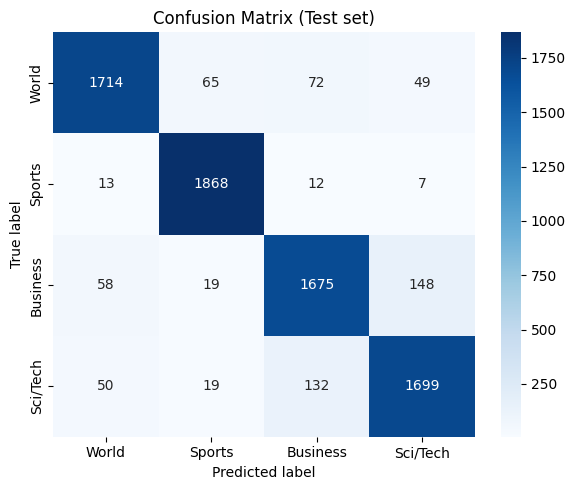


Classification report:

              precision    recall  f1-score   support

       World     0.9341    0.9021    0.9178      1900
      Sports     0.9477    0.9832    0.9651      1900
    Business     0.8858    0.8816    0.8837      1900
    Sci/Tech     0.8928    0.8942    0.8935      1900

    accuracy                         0.9153      7600
   macro avg     0.9151    0.9153    0.9150      7600
weighted avg     0.9151    0.9153    0.9150      7600



In [ ]:
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


@torch.no_grad()
def get_preds_and_labels(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Collecting preds", leave=False):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, lengths)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)

test_preds, test_labels = get_preds_and_labels(model, test_loader)

# F1 macro
f1_macro = f1_score(test_labels, test_preds, average="macro")
print("F1 macro:", f1_macro)

# Matriz de confusión:

# nombres de clases
class_names = ds["train"].features["label"].names

# calcular matriz (si no la tienes ya)
cm = confusion_matrix(test_labels, test_preds)

# tamaño de figura
plt.figure(figsize=(6,5))

# heatmap
sns.heatmap(
    cm,
    annot=True,           # mostrar números
    fmt="d",              # formato entero
    cmap="Blues",         # paleta de colores
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test set)")
plt.tight_layout()
plt.show()

# Reporte por clase
target_names = ds["train"].features["label"].names
print("\nClassification report:\n")
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

| Clase        | Desempeño         | Interpretación                                                                                  | Posibles causas de error                                                                             |
| ------------ | ----------------- | ----------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| **World**    | Alto              | El modelo distingue bien noticias internacionales y políticas globales.                         | Puede confundirse con *Business* cuando la noticia trata de economía global o políticas comerciales. |
| **Sports**   | Muy alto | Es la clase mejor identificada; tiene vocabulario muy distintivo (equipos, torneos, jugadores). | Pocas confusiones; ocasionalmente con *World* si se menciona contexto internacional.                 |
| **Business** | Medio-alto        | Es la clase más difícil; comparte vocabulario con economía, tecnología y política.              | Frecuente confusión con *Sci/Tech* (empresas tecnológicas) y *World* (economía internacional).       |
| **Sci/Tech** | Medio-alto        | Buen desempeño general, pero con cierta superposición semántica.                                | Puede confundirse con *Business* cuando se habla de startups, mercados tecnológicos o compañías.     |
